In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import joblib 
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

In [5]:
df=pd.read_csv(r"C:\Users\Digoju Prabhukumar\Downloads\car_data.csv")

In [6]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
df.shape

(301, 9)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [10]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(2)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [14]:
print('\nFuel Type:')
print(df["Fuel_Type"].value_counts())
print("\nSeller_Type:")
print(df["Seller_Type"].value_counts())
print("\nTransmission:")
print(df["Transmission"].value_counts())
print("\nOwner:")
print(df["Owner"].value_counts())


Fuel Type:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Seller_Type:
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

Owner:
Owner
0    288
1     10
3      1
Name: count, dtype: int64


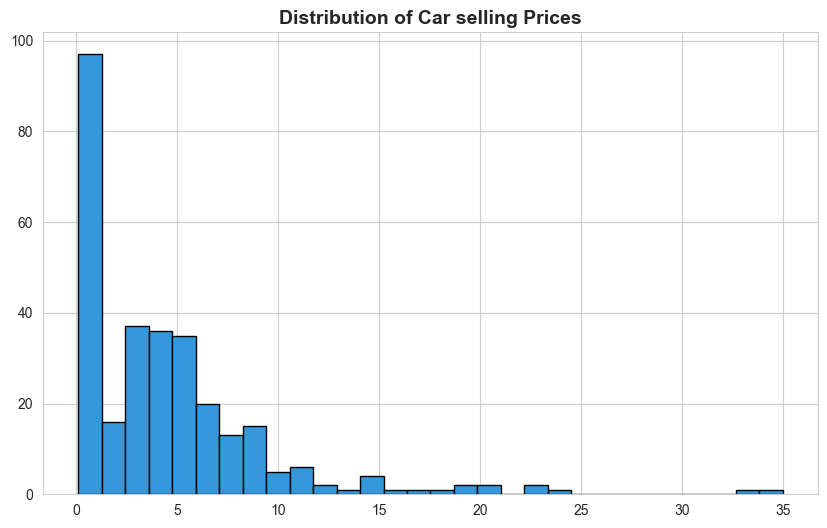

In [18]:
plt.figure(figsize=(10,6))
plt.hist(df["Selling_Price"],bins=30,color="#3498db",edgecolor="black")
plt.title("Distribution of Car selling Prices",fontsize=14,fontweight='bold')
plt.show()

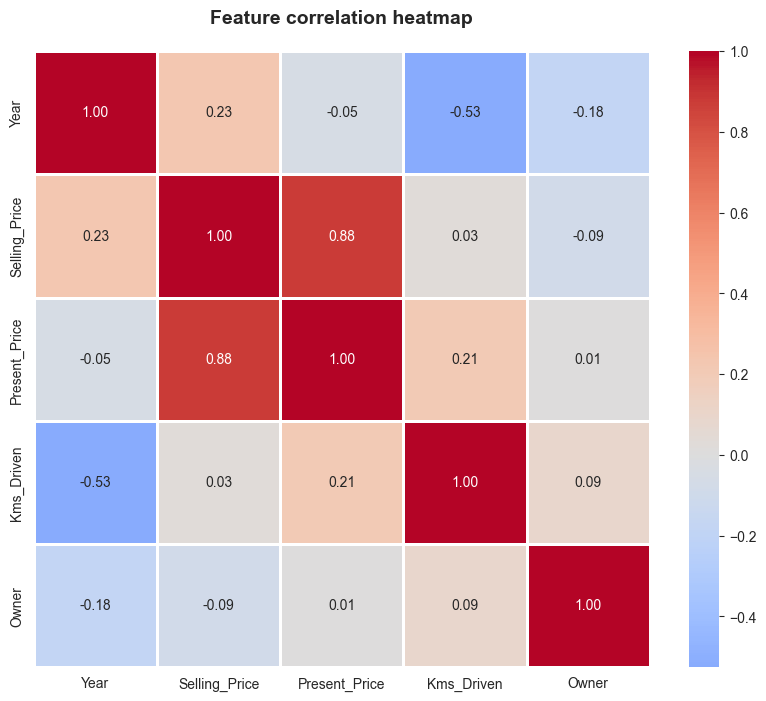

In [19]:
plt.figure(figsize=(10,8))
numeric_data=df.select_dtypes(include=[np.number])
correlation=numeric_data.corr()
sns.heatmap(correlation,annot=True,cmap='coolwarm',center=0,square=True,linewidth=1,fmt=".2f")
plt.title("Feature correlation heatmap",fontsize=14,fontweight='bold',pad=20)
plt.show()

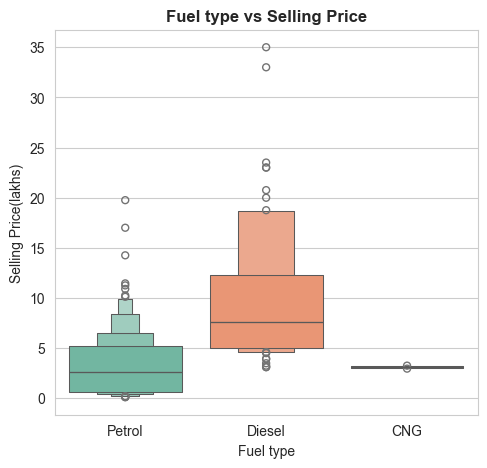

In [25]:
# Fuel type vs selling price

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxenplot(x="Fuel_Type",y="Selling_Price",data=df,palette="Set2")
plt.title("Fuel type vs Selling Price",fontweight='bold')
plt.xlabel("Fuel type")
plt.ylabel("Selling Price(lakhs)")
plt.show()

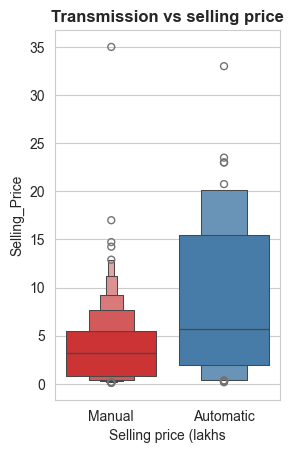

In [27]:
# Transmission vs selling price
plt.subplot(1,2,2)
sns.boxenplot(x="Transmission",y="Selling_Price",data=df,palette="Set1")
plt.title("Transmission vs selling price",fontweight='bold')
plt.xlabel("Selling price (lakhs")
plt.show()

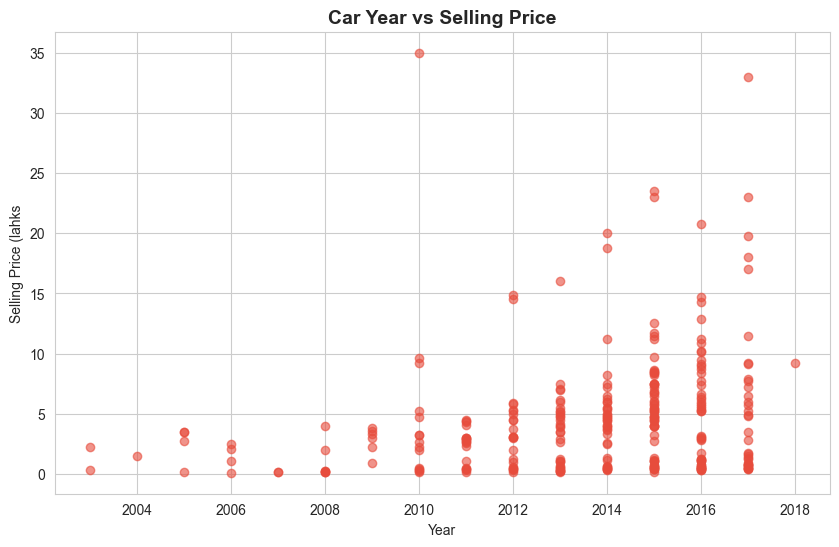

In [28]:
# Year vs selling price

plt.figure(figsize=(10,6))
plt.scatter(df["Year"],df["Selling_Price"],alpha=0.6,c="#e74c3c")
plt.title("Car Year vs Selling Price",fontsize=14,fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Selling Price (lahks")
plt.show()

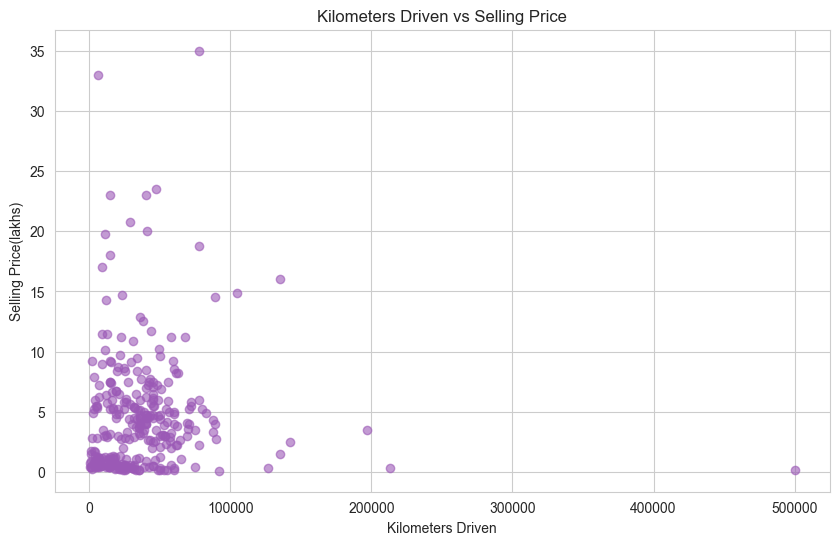

In [29]:
 # Kms driven vs Selling price

plt.figure(figsize=(10,6))
plt.scatter(df["Kms_Driven"],df["Selling_Price"],alpha=0.6,c="#9b59b6")
plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price(lakhs)")
plt.show()

In [32]:
# Encoding 

df.replace({"Fuel_Type":{"Petrol":0,"Diesel":1,"CNG":2}},inplace=True)
df.replace({"Seller_Type":{"Dealer":0,"Individual":1}},inplace=True)
df.replace({"Transmission":{"Manual":0,"Automatic":1}},inplace=True)
print("Encoded Dataset")
df.head()

Encoded Dataset


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [33]:
X=df.drop(["Car_Name","Selling_Price"],axis=1)
y=df["Selling_Price"]
print(X.head())

   Year  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  Owner
0  2014           5.59       27000         0           0            0      0
1  2013           9.54       43000         1           0            0      0
2  2017           9.85        6900         0           0            0      0
3  2011           4.15        5200         0           0            0      0
4  2014           6.87       42450         1           0            0      0


In [34]:
print(y.head())

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [35]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [39]:
print(f"Testing Samples:{X_test.shape[0]} (20%)")
print(f"Training Samples:{X_train.shape[0]} (20%)")

Testing Samples:60 (20%)
Training Samples:239 (20%)


## Linear Regression

In [41]:
# Model LinearRegression

lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)

train_pred_lr=lin_reg.predict(X_train)
train_r2_lr=metrics.r2_score(y_train,train_pred_lr)
train_mae_lr=metrics.mean_absolute_error(y_train,train_pred_lr)
train_rmse=np.sqrt(metrics.mean_squared_error(y_train,train_pred_lr))

print("r2_score:", train_r2_lr)
print("mae:",train_mae_lr)
print("rmse:",train_rmse)

r2_score: 0.8830066323340686
mae: 1.1674333150582783
rmse: 1.764309816079347


In [42]:

test_pred_lr=lin_reg.predict(X_test)
test_r2_lr=metrics.r2_score(y_test,test_pred_lr)
test_mae_lr=metrics.mean_absolute_error(y_test,test_pred_lr)
test_rmse=np.sqrt(metrics.mean_squared_error(y_test,test_pred_lr))

print("r2_score:", test_r2_lr)
print("mae:",test_mae_lr)
print("rmse:",test_rmse)

r2_score: 0.7895030781337816
mae: 1.1951253620342661
rmse: 1.8715621184976818


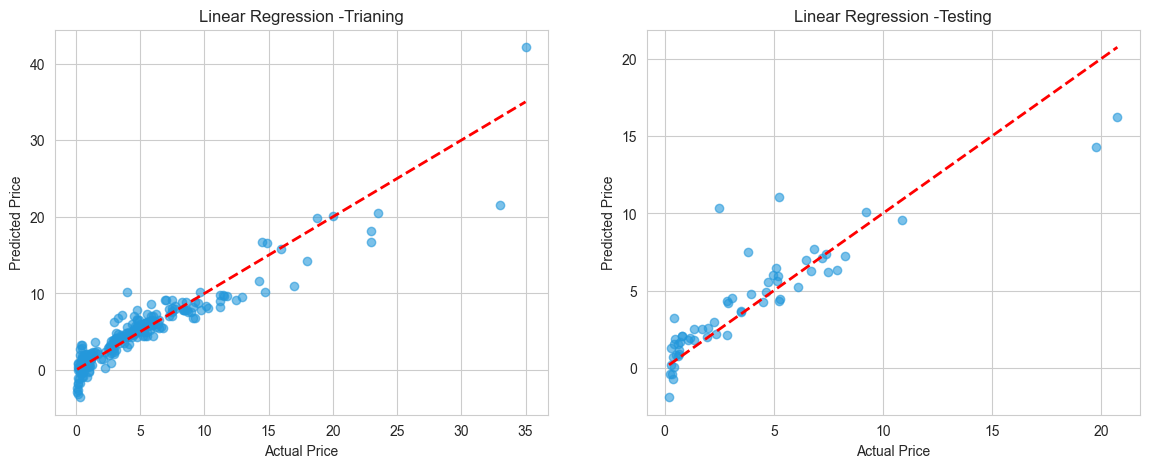

In [54]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].scatter(y_train,train_pred_lr,alpha=0.6,color="#2498db")
axes[0].plot(
    [y_train.min(),y_train.max()],
    [y_train.min(),y_train.max()],
    "r--",lw=2)

axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Linear Regression -Trianing")

axes[1].scatter(y_test,test_pred_lr,alpha=0.6,color="#2498db")
axes[1].plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()]
    ,"r--",lw=2)
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("Linear Regression -Testing")

plt.show()

## Lasso regression

In [58]:
# Model LinearRegression
from sklearn.linear_model import Lasso
lasso_reg=Lasso()
lasso_reg.fit(X_train,y_train)

train_pred_lr=lasso_reg.predict(X_train)
train_r2_lr=metrics.r2_score(y_train,train_pred_lr)
train_mae_lr=metrics.mean_absolute_error(y_train,train_pred_lr)
train_rmse=np.sqrt(metrics.mean_squared_error(y_train,train_pred_lr))

print("r2_score:", train_r2_lr)
print("mae:",train_mae_lr)
print("rmse:",train_rmse)

r2_score: 0.8529189838538876
mae: 1.2253328420056386
rmse: 1.9782106701504707


In [59]:

test_pred_lr=lasso_reg.predict(X_test)
test_r2_lr=metrics.r2_score(y_test,test_pred_lr)
test_mae_lr=metrics.mean_absolute_error(y_test,test_pred_lr)
test_rmse=np.sqrt(metrics.mean_squared_error(y_test,test_pred_lr))

print("r2_score:", test_r2_lr)
print("mae:",test_mae_lr)
print("rmse:",test_rmse)

r2_score: 0.7388499970676028
mae: 1.4035494304972675
rmse: 2.084617546863688


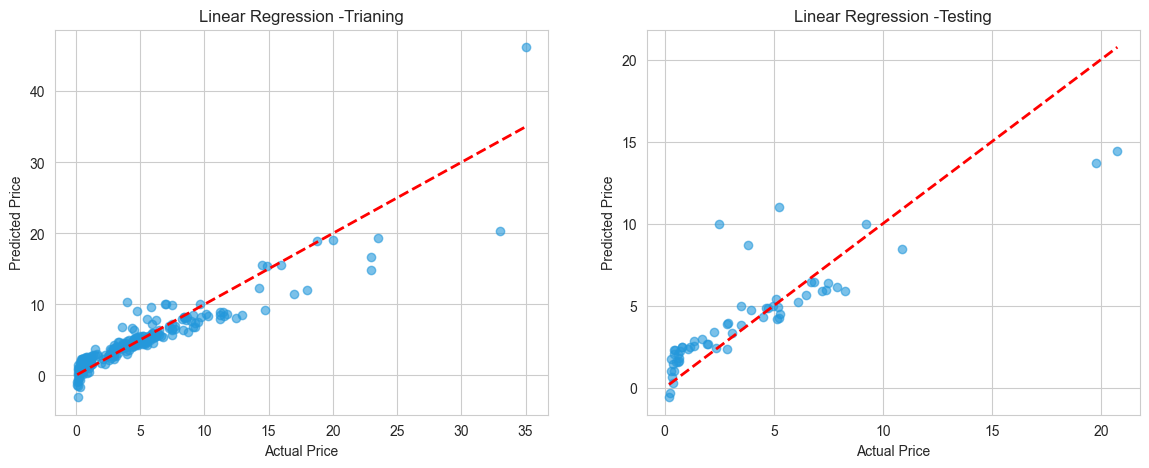

In [60]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].scatter(y_train,train_pred_lr,alpha=0.6,color="#2498db")
axes[0].plot(
    [y_train.min(),y_train.max()],
    [y_train.min(),y_train.max()],
    "r--",lw=2)

axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Linear Regression -Trianing")

axes[1].scatter(y_test,test_pred_lr,alpha=0.6,color="#2498db")
axes[1].plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()]
    ,"r--",lw=2)
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("Linear Regression -Testing")

plt.show()

## RandomForest

In [72]:
# Model LinearRegression
from sklearn.ensemble import RandomForestRegressor
rf_reg=RandomForestRegressor(n_estimators=100,random_state=2)
rf_reg.fit(X_train,y_train)

train_pred_rf=rf_reg.predict(X_train)
train_r2_rf=metrics.r2_score(y_train,train_pred_rf)
train_mae_rf=metrics.mean_absolute_error(y_train,train_pred_rf)
train_rmse=np.sqrt(metrics.mean_squared_error(y_train,train_pred_rf))

print("r2_score:", train_r2_rf)
print("mae:",train_mae_rf)
print("rmse:",train_rmse)

r2_score: 0.9885015310694824
mae: 0.24191464435146404
rmse: 0.5531134728888938


In [73]:

test_pred_rf=lasso_reg.predict(X_test)
test_r2_rf=metrics.r2_score(y_test,test_pred_rf)
test_mae_rf=metrics.mean_absolute_error(y_test,test_pred_rf)
test_rmse=np.sqrt(metrics.mean_squared_error(y_test,test_pred_rf))

print("r2_score:", test_r2_rf)
print("mae:",test_mae_rf)
print("rmse:",test_rmse)

r2_score: 0.7388499970676028
mae: 1.4035494304972675
rmse: 2.084617546863688


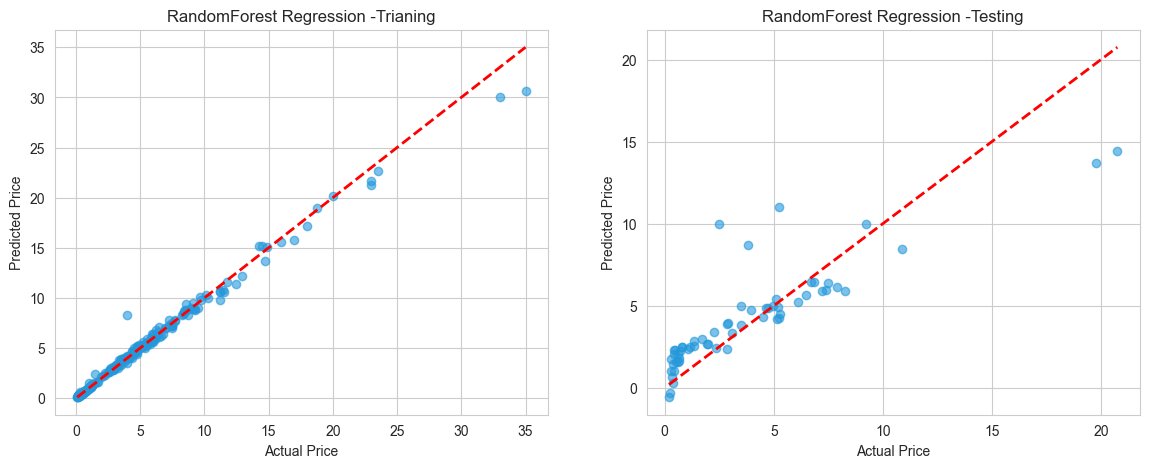

In [74]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].scatter(y_train,train_pred_rf,alpha=0.6,color="#2498db")
axes[0].plot(
    [y_train.min(),y_train.max()],
    [y_train.min(),y_train.max()],
    "r--",lw=2)

axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("RandomForest Regression -Trianing")

axes[1].scatter(y_test,test_pred_rf,alpha=0.6,color="#2498db")
axes[1].plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()]
    ,"r--",lw=2)
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("RandomForest Regression -Testing")

plt.show()

## KNeighborsRegressor

In [68]:
from sklearn.neighbors import KNeighborsRegressor
knn_reg=KNeighborsRegressor()
knn_reg.fit(X_train,y_train)

train_pred_knn=knn_reg.predict(X_train)
train_r2_knn=metrics.r2_score(y_train,train_pred_knn)
train_mae_knn=metrics.mean_absolute_error(y_train,train_pred_knn)
train_rmse=np.sqrt(metrics.mean_squared_error(y_train,train_pred_knn))

print("r2_score:", train_r2_knn)
print("mae:",train_mae_knn)
print("rmse:",train_rmse)

r2_score: 0.29704384249101135
mae: 2.995573221757322
rmse: 4.3247235275747


In [69]:

test_pred_knn=knn_reg.predict(X_test)
test_r2_knn=metrics.r2_score(y_test,test_pred_knn)
test_mae_knn=metrics.mean_absolute_error(y_test,test_pred_knn)
test_rmse=np.sqrt(metrics.mean_squared_error(y_test,test_pred_knn))

print("r2_score:", test_r2_knn)
print("mae:",test_mae_knn)
print("rmse:",test_rmse)

r2_score: -0.3403896448259973
mae: 3.400766666666667
rmse: 4.722771170968729


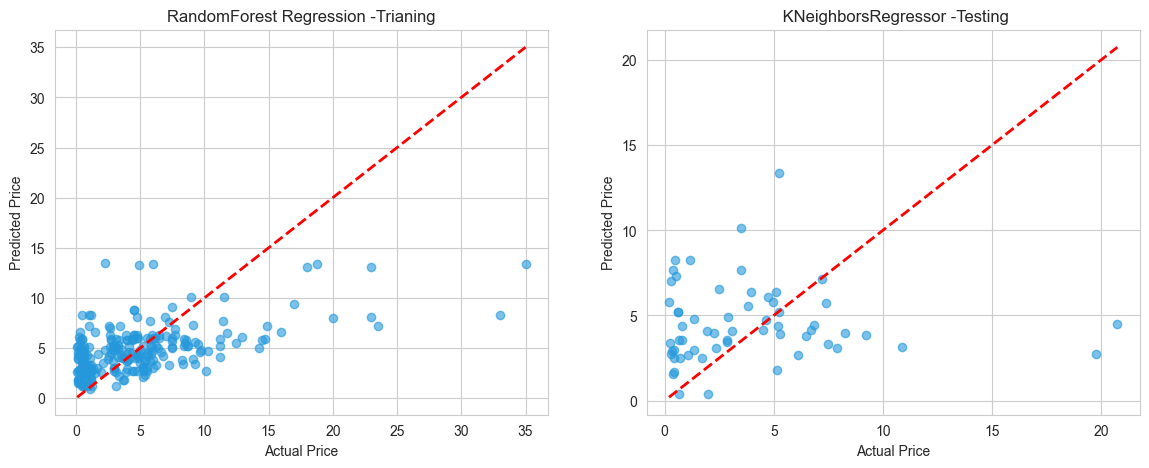

In [70]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].scatter(y_train,train_pred_knn,alpha=0.6,color="#2498db")
axes[0].plot(
    [y_train.min(),y_train.max()],
    [y_train.min(),y_train.max()],
    "r--",lw=2)

axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("RandomForest Regression -Trianing")

axes[1].scatter(y_test,test_pred_knn,alpha=0.6,color="#2498db")
axes[1].plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()]
    ,"r--",lw=2)
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title(" KNeighborsRegressor -Testing")

plt.show()

In [75]:
feature_importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf_reg.feature_importances_}).sort_values('Importance',ascending=False)

print(feature_importance)

         Feature  Importance
1  Present_Price    0.897698
0           Year    0.074640
2     Kms_Driven    0.019206
3      Fuel_Type    0.004196
5   Transmission    0.002372
4    Seller_Type    0.001871
6          Owner    0.000016


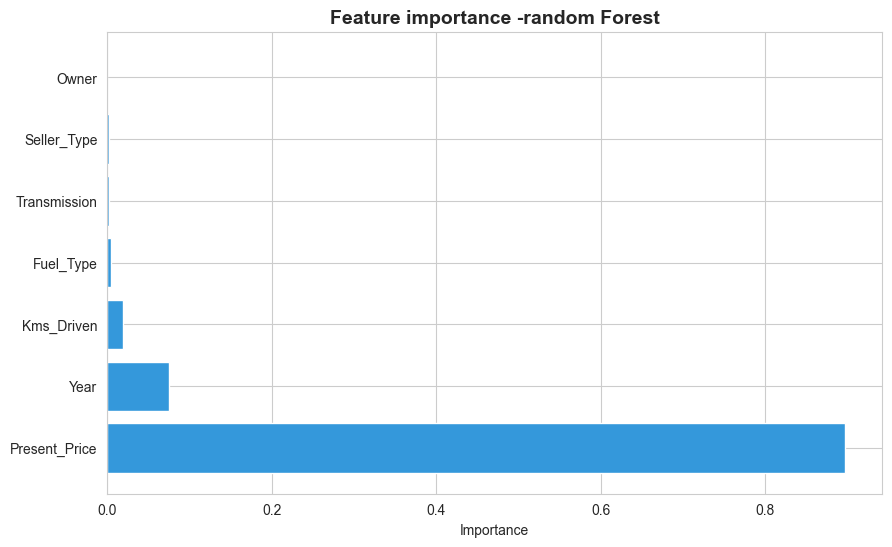

In [77]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"],feature_importance["Importance"],color="#3498db")
plt.xlabel("Importance")
plt.title("Feature importance -random Forest",fontsize=14,fontweight="bold")
plt.show()

In [84]:
# Save Best model
joblib.dump(rf_reg,"Car_price_prediction.pkl")

['Car_price_prediction.pkl']

In [81]:
X_train.head()

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
54,2005,10.21,90000,0,1,0,0
174,2015,0.72,38600,0,1,0,0
24,2013,4.41,56879,0,0,0,0
100,2016,1.90,3000,0,1,0,0
246,2012,6.79,35000,0,0,0,0


In [83]:
input_data=pd.DataFrame({
    "Year":[2015],
    "Present_Price":[7.0],
    "Kms_Driven":[50000],
    "Fuel_Type":[0],
    "Seller_Type":[1],
    "Transmission":[0],
    "Owner":[1]
})

prediction=rf_reg.predict(input_data)[0]
print(prediction)

4.1685
